Source: https://levelup.gitconnected.com/building-a-training-architecture-for-self-improving-ai-agents-c87a4e316b22

In [1]:
import pandas as pd
from datasets import load_dataset
from typing import List, TypedDict
from dotenv import load_dotenv

load_dotenv()

True

### Dataset Management 

In [2]:

class ResearchTask(TypedDict):
    id: str                  # The unique PubMed ID for the article
    goal: str                # The research question our agent must investigate
    context: str             # The full scientific abstract providing the necessary evidence
    expected_decision: str   # The ground truth answer ('yes', 'no', or 'maybe')

In [3]:
dataset = load_dataset("pubmed_qa", "pqa_labeled", trust_remote_code=True)

Using the latest cached version of the dataset since pubmed_qa couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'pqa_labeled' at /home/bmartins/.cache/huggingface/datasets/pubmed_qa/pqa_labeled/0.0.0/9001f2853fb87cab8d220904e0de81ac6973b318 (last modified on Thu Jan 22 21:58:00 2026).


In [4]:
def load_and_preare_dataset() -> tuple[List[ResearchTask], List[ResearchTask]]:
    """
    Downloads, processes and splits the PubMed dataset into training and validation sets.
    """
    dataset = load_dataset("pubmed_qa", "pqa_labeled", trust_remote_code=True)
    # convert training dataset to dataframe for easier processing
    df = dataset["train"].to_pandas()
    # list for the structured research tasks 
    research_tasks = []
    # iterate through each row of the dataframe to create tasks 
    for _, row in df.iterrows():
        #print(row)
        context_str = "".join(row['context'])
        task = ResearchTask(
            id=str(row['pubid']),
            goal=row['question'],
            context=context_str,
            expected_decision=row['final_decision']
        )
        research_tasks.append(task)

    train_size = int(0.8 * len(research_tasks))
    train_set = research_tasks[:train_size]
    val_set = research_tasks[train_size:]

    print(f'Dataset downloaded. Size: {len(research_tasks)}')
    return train_set, val_set

In [5]:
train_set, val_set = load_and_preare_dataset()

Using the latest cached version of the dataset since pubmed_qa couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'pqa_labeled' at /home/bmartins/.cache/huggingface/datasets/pubmed_qa/pqa_labeled/0.0.0/9001f2853fb87cab8d220904e0de81ac6973b318 (last modified on Thu Jan 22 21:58:00 2026).


Dataset downloaded. Size: 1000


In [6]:
from rich.console import Console
from rich.table import Table 

console = Console()

def display_dataset(dataset: List[ResearchTask], sample_size=5):
    """
    Displays a sample of the dataset. 
    """
    table = Table(title="Pubmed research goals dataset")
    table.add_column("ID", style="cyan")
    table.add_column("Research goal (Question)", style="magenta")
    table.add_column("Expected Decision", style="green")

    for item in dataset[:sample_size]:
        table.add_row(item['id'], item['goal'], item['expected_decision'])

    console.print(table)

display_dataset(train_set)

                                           Pubmed research goals dataset                                           
┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ ID       ┃ Research goal (Question)                                                         ┃ Expected Decision ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ 21645374 │ Do mitochondria play a role in remodelling lace plant leaves during programmed   │ yes               │
│          │ cell death?                                                                      │                   │
│ 16418930 │ Landolt C and snellen e acuity: differences in strabismus amblyopia?             │ no                │
│ 9488747  │ Syncope during bathing in infants, a pediatric form of water-induced urticaria?  │ yes               │
│ 17208539 │ Are the long-term results of the transanal pull-through equal to those of the    │ no                │
│          │ transabdominal pull-through?                                                     │                   │
│ 10808977 │ Can tailored interventions increase mammography use among HMO women?             │ yes               │
└──────────┴──────────────────────────────────────────────────────────────────────────────────┴───────────────────┘

### Define Junior Researcher 

In [7]:
from typing import List, TypedDict, Literal
from langchain_core.messages import BaseMessage 

class JuniorResearch(TypedDict):
    hypothesis: str 
    supporting_papers: List[str]
    agent_name: str # track which junior researcher proposed the hypothesis

### Define Experimental Protocol 

In [8]:
class Protocol(TypedDict):
    title: str 
    steps: List[str]
    safety_concerns: str
    budget_usd: str

### Feedback from review board

In [9]:
class ReviewDecision(TypedDict):
   decision: Literal['APPROVE', 'REVISE']
   critique_severity: Literal['CRITICAL', 'MAJOR', 'MINOR']
   feedback: str 

### Define main Agent State

In [10]:
from typing import Annotated

class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], lambda x, y: x + y] # merge the field by appending new messages 
    research_goal: str # initial high level goal 
    sender: str # tracks which agent acted last 
    turn_count: int # counter to prevent infinite loops 
    # Junior research initial response
    initial_hypotheses: List[JuniorResearch]
    # Selected hypothesis  
    selected_hypothesis: JuniorResearch
    supervisor_justification: str 
    
    # Senior research team output 
    refined_hypothesis: str 
    experimental_protocol: Protocol

    # Review board's output 
    peer_review: ReviewDecision
    safety_review: ReviewDecision

    # Principal investigator's final decision
    final_protocol: Protocol 
    final_decision: Literal['GO', 'NO-GO']
    final_rationale: str

    # The final evaluation score from reward function 
    final_evaluation: dict 



### Information Flow 

1. initial hypotheses
2. selected hypothesis
3. experimental protocol 
4. peer review 
5. safety review 
6. final decision

In [11]:
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults


class ScientificToolkit:
    def __init__(self):
        # Initialize the Tavily search client, configured to return the top 5 results.
        self.tavily = TavilySearchResults(max_results=5)
        # This is a mock database simulating an internal resource for protein information.
        self.mock_protein_db = {
            "amyloid-beta": "A key protein involved in the formation of amyloid plaques in Alzheimer's.",
            "tau": "A protein that forms neurofibrillary tangles inside neurons in Alzheimer's.",
            "apoe4": "A genetic risk factor for Alzheimer's disease, affecting lipid metabolism in the brain.",
            "trem2": "A receptor on microglia that, when mutated, increases Alzheimer's risk.",
            "glp-1": "Glucagon-like peptide-1, a hormone involved in insulin regulation with potential neuroprotective effects."
        }
        # This is a second mock database, this time for gene functions.
        self.mock_go_db = {
            "apoe4": "A major genetic risk factor for Alzheimer's disease, involved in lipid transport and amyloid-beta clearance.",
            "trem2": "Associated with microglial function, immune response, and phagocytosis of amyloid-beta."
        }
        
        # Create tools that capture self via closure
        self.pubmed_search = self._create_pubmed_search()
        self.clinical_trials_search = self._create_clinical_trials_search()
        self.protein_database_lookup = self._create_protein_database_lookup()
        self.gene_ontology_lookup = self._create_gene_ontology_lookup()

    def _create_pubmed_search(self):
        tavily = self.tavily
        @tool
        def pubmed_search(query: str) -> str:
            """
            Searches PubMed for biomedical literature. 
            Use highly specific keywords related to genes, proteins, and disease mechanisms.
            """
            console.print(f"--- TOOL: PubMed Search, Query: {query} ---")
            return tavily.invoke(f"site:pubmed.ncbi.nlm.nih.gov {query}")
        return pubmed_search

    def _create_clinical_trials_search(self):
        tavily = self.tavily
        @tool
        def clinical_trials_search(query: str) -> str:
            """
            Searches for information on clinical trials related to specific drugs or therapies.
            """
            console.print(f"--- TOOL: Clinical Trials Search, Query: {query} ---")
            return tavily.invoke(f"site:clinicaltrials.gov {query}")
        return clinical_trials_search

    def _create_protein_database_lookup(self):
        db = self.mock_protein_db
        @tool
        def protein_database_lookup(protein_name: str) -> str:
            """
            Looks up information about a specific protein in our mock database. 
            """
            console.print(f"--- TOOL: Protein DB Lookup, protein: {protein_name} ---")
            return db.get(protein_name.lower(), "Protein not found")
        return protein_database_lookup

    def _create_gene_ontology_lookup(self):
        db = self.mock_go_db
        @tool
        def gene_ontology_lookup(gene_symbol: str) -> str:
            """
            Looks up the function and pathways associated with a specific gene symbol in the Gene Ontology database 
            """ 
            console.print(f"--- TOOL: Gene Ontology Lookup, Gene: {gene_symbol.upper()} ---")
            result = db.get(gene_symbol.lower(), f"Gene '{gene_symbol}' not found in ontology database.")
            console.print(f"Gene '{gene_symbol.upper()}' lookup result: {result}")
            return result
        return gene_ontology_lookup

### Toolkit instantiation

In [12]:
toolkit = ScientificToolkit()
all_tools = [
    toolkit.pubmed_search, 
    toolkit.clinical_trials_search, 
    toolkit.protein_database_lookup,
    toolkit.gene_ontology_lookup
    ]
toolkit.gene_ontology_lookup.invoke("APOE4")

/tmp/ipykernel_2604000/2461167154.py:8: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  self.tavily = TavilySearchResults(max_results=5)


--- TOOL: Gene Ontology Lookup, Gene: APOE4 ---

Gene 'APOE4' lookup result: A major genetic risk factor for Alzheimer's disease, involved in lipid transport and 
amyloid-beta clearance.

"A major genetic risk factor for Alzheimer's disease, involved in lipid transport and amyloid-beta clearance."

### Society of Scientists

In [13]:
import os 
from langchain_ollama import ChatOllama 
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

junior_researcher_llm = ChatOllama(
    model="qwen3:8b",
    temperature = 0.5
)
supervisor_llm = ChatOllama(
    model="qwen3:8b",
    temperature = 0.0 
)
senior_researcher_llm = ChatOllama(
    model="qwen3:32b", 
    temperature=0.1 
)
review_board_llm = ChatOllama(
    model="qwen3:32b", 
    temperature=0.0
)

In [14]:
def create_agent_runner(llm, system_prompt, tools):
    """
    A Factory function to create a runnable agent executor. 
    """
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages") 
    ])
    return prompt | llm.bind_tools(tools)


In [15]:
import yaml

with open("prompts.yaml", "r") as f:
    prompts = yaml.safe_load(f)

In [16]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode 
from langchain_core.messages import HumanMessage, BaseMessage
import json 

MAX_TURNS = 15 # safeguard to prevent graph from getting stuck 

def create_agent_node(agent_name: str, agent_runner): 
    """
    Create a Langraph node function for a given agent runner 
    """
    def agent_node(state: AgentState) -> dict:
        console.print(f"--- Node: {agent_name} (Turn {state['turn_count']}) ---")
        state['turn_count'] += 1
        result = agent_runner.invoke(state)

        if agent_name in ["PeerReviewer", "SafetyOfficer"]:
            try: 
                content = json.loads(result.content)
                if agent_name == "PeerReviewer":
                    state['peer_review'] = content 
                else:
                    state['safety_review'] = content
            except (json.JSONDecodeError, TypeError):
                console.print(f"[bold red]Error parsing JSON from {agent_name}: {result.content}[/bold red]")
        return {"messages": [result], "sender": agent_name}
    return agent_node

### Tools condition

In [17]:
def tools_condition(state: AgentState) -> str:
    """
    A conditional edge that checks for tool calls and the turn count. 
    """
    # Get the most recent message in the state 
    last_message = state['messages'][-1]

    # if the message has no tool calls, the agent's turn is done 
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return "end"

    # end if exceeded maximum number of calls 
    if state['turn_count'] >= MAX_TURNS:
        console.print("[bold yellow]Max turns reached. Ending graph. [/bold yellow] ")
        return "end"

    return "tools" 

### Route after tools

In [18]:
def route_after_tools(state: AgentState) -> str:
    """
    A router that sends the workflow back to the agent that initiated the tool call.
    """
    # Get the name of the last agent that acted from the 'sender' field in the state 
    sender = state.get("sender")
    console.print(f"--- Routing back to: {sender} after tool execution ---")
    if not sender:
        # if sender is not set we end the graph as fallback 
        return END 
    return sender 

### Multi-level revision loop

In [19]:
def route_after_review(state: AgentState) -> Literal["PrincipalInvestigator", "HypothesisRefiner", "ProtocolDesigner"]:
    """
    An intelligent router that determines the next step based on the severity of review feedback    
    """
    peer_review = state.get("peer_review", {})
    safety_review = state.get("safety_review", {})

    # Extract the decision and severity from both reviews, with safe defaults.
    peer_severity = peer_review.get("critique_severity", "MINOR")
    safety_severity = safety_review.get("critique_severity", "MINOR")

    # If our safety counter is maxed out, we must proceed to the PI, regardless of feedback 
    if state["turn_count"] >= MAX_TURNS:
        console.print("[bold yellow] Max turns reached during review. Proceeding to Principal Investigator [/bold yellow]")
        return "PrincipalInvestigator"

    # if either review has a 'CRITICAL' severity, the fundamental hypothesis is flawed
    # we route back to the HypothesisRefiner for a major rethink
    if peer_severity == "CRITICAL" or safety_severity == "CRITICAL":
        console.print("---Review requires CRITICAL revision, routing back to HypothesisRefiner ---")
        state['messages'].append(HumanMessage(content="Critical feedback received. The core hypothesis needs rethinking."))
        return "HypothesisRefiner"

    # if either review had a 'MAJOR' severity but no critical ones, the protocol itself is flawed 
    # we route back to the ProtocolDesigner for a significant revision
    if peer_severity == 'MAJOR' or safety_severity == 'MAJOR':
        console.print("--- Review requires MAJOR revision, routing back to ProtocolDesigner ---")
        state['messages'].append(HumanMessage(content="Major feedback received. The protocol needs significant revision."))
        return "ProtocolDesigner"

    # if there are only MINOR revisions or everything is approved, the protocol is sound
    # we can proceed to PrincipalInvestigator for the final decision 
    console.print("--- Reviews complete, routing to the PrincipalInvestigator ---")
    return "PrincipalInvestigator"

In [20]:
def build_graph() -> StateGraph: 
    workflow = StateGraph(AgentState)

    #Instantiate all our agent runners using the factory function.
    agent_runners = {
        "Geneticist": create_agent_runner(junior_researcher_llm, prompts['Geneticist'], all_tools),
        "Pharmacologist": create_agent_runner(junior_researcher_llm, prompts["Pharmacologist"], all_tools), 
        "Neurologist": create_agent_runner(junior_researcher_llm, prompts["Neurologist"], all_tools),
        "Supervisor": create_agent_runner(supervisor_llm, prompts["Supervisor"], []),
        "HypothesisRefiner": create_agent_runner(senior_researcher_llm, prompts["HypothesisRefiner"], all_tools),
        "ProtocolDesigner": create_agent_runner(senior_researcher_llm, prompts["ProtocolDesigner"], all_tools),
        "PeerReviewer": create_agent_runner(review_board_llm, prompts["PeerReviewer"], []),
        "SafetyOfficer": create_agent_runner(review_board_llm, prompts["SafetyOfficer"], []),
        "PrincipalInvestigator": create_agent_runner(review_board_llm, prompts["PrincipalInvestigator"], [])
    }

    # Add all the agent nodes and the single tool execution node to the graph
    for name, runner in agent_runners.items():
        workflow.add_node(name, create_agent_node(name, runner))
    workflow.add_node("execute_tools", ToolNode(all_tools))

    # --- define the graph's control flow using edges ---

    # The graph starts by running the three Junior Researchers in parallel 
    workflow.add_edge(START, "Geneticist")
    workflow.add_edge(START, "Pharmacologist")
    workflow.add_edge(START, "Neurologist")

    # For each agent that can use tools, we add the ReAct conditional edge 
    for agent_name in ["Geneticist", "Pharmacologist", "Neurologist", "HypothesisRefiner", "ProtocolDesigner"]: 
        workflow.add_conditional_edges(
            agent_name, 
            tools_condition,
            {
                "tools": "execute_tools", 
                "end": "Supervisor" if agent_name in ["Geneticist", "Pharmacologist", "Neurologist"] else "ProtocolDesigner" if agent_name == "HypothesisRefiner" else "PeerReviewer"
            }
        )
    
    # After tools are executed route back to the agent that called them 
    workflow.add_conditional_edges("execute_tools", route_after_tools)

    # Define the main linear flow of the research pipeline 
    workflow.add_edge("Supervisor", "HypothesisRefiner")
    workflow.add_edge("PeerReviewer", "SafetyOfficer")

    # After the safety officer use the intelligent review router 
    workflow.add_conditional_edges("SafetyOfficer", route_after_review)

    # the PrincipalInvestigator is the final step before the graph ends 
    workflow.add_edge("PrincipalInvestigator", END)

    return workflow
    


Langgraph StateGraph builder is defined and compiled.


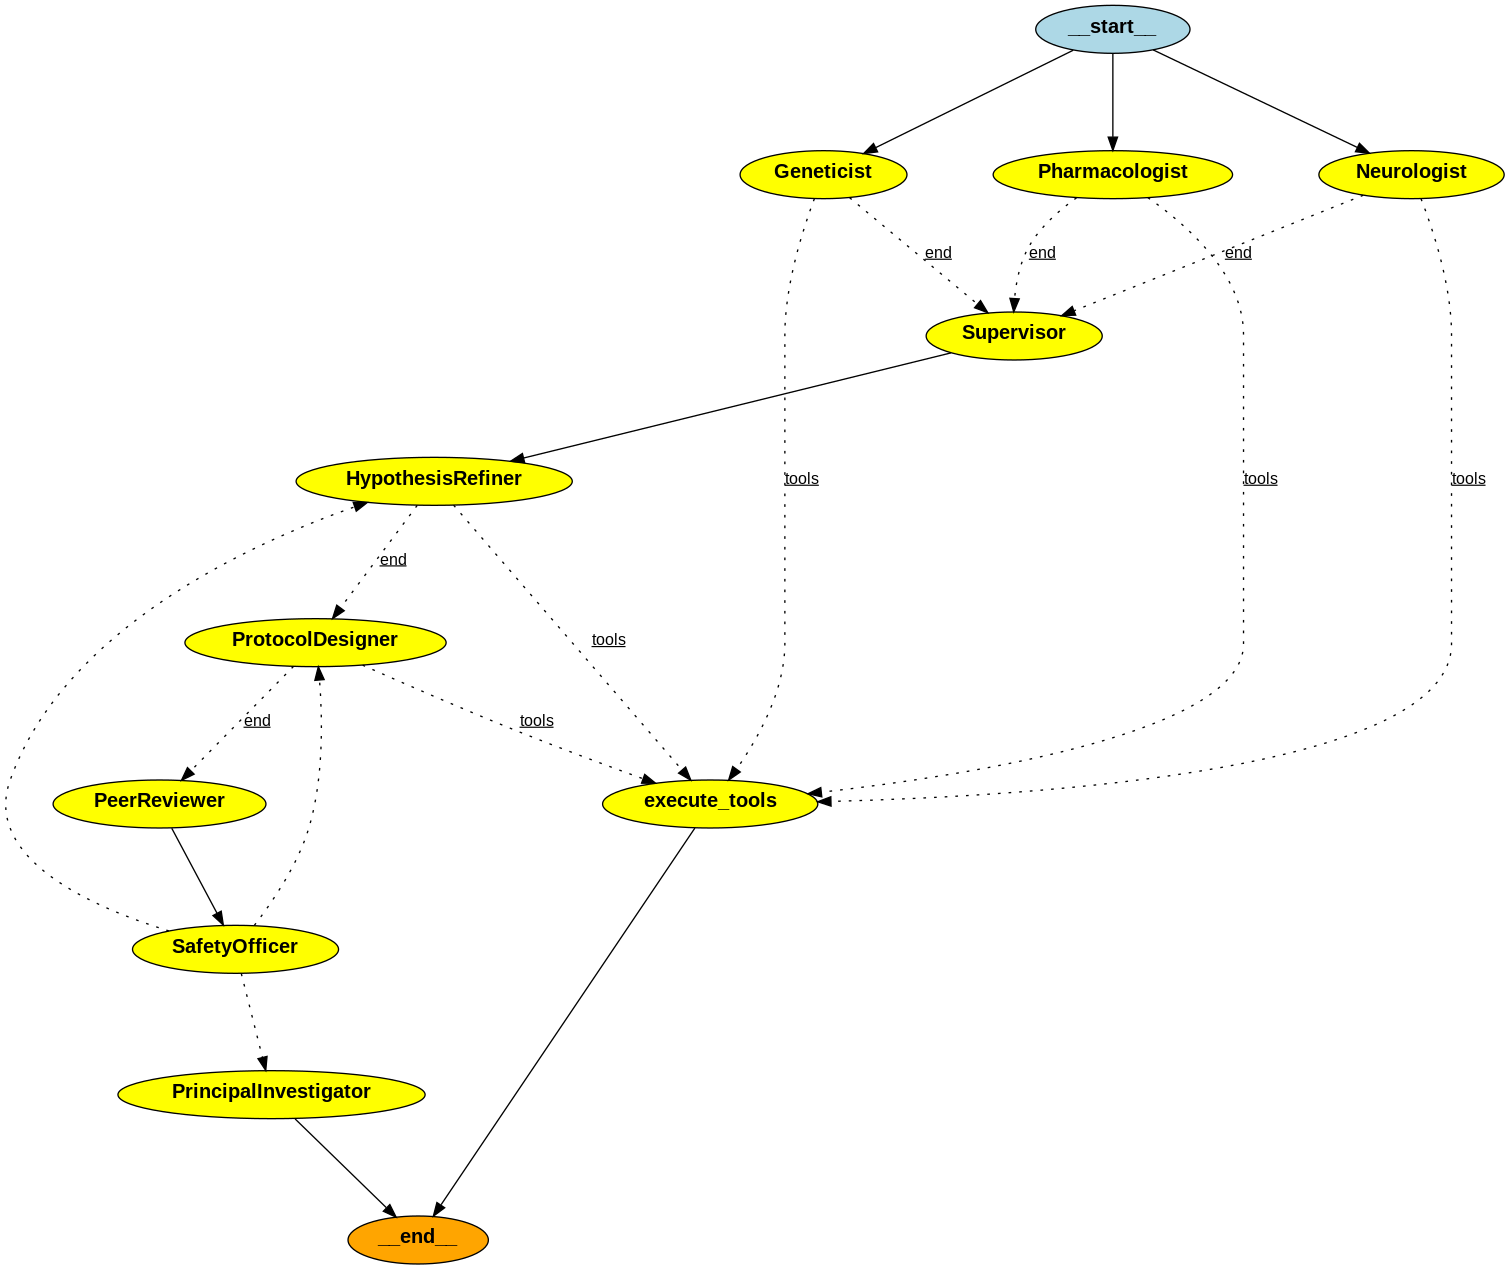

In [21]:
from IPython.display import Image, display
research_graph_builder = build_graph()
research_graph = research_graph_builder.compile()
print("Langgraph StateGraph builder is defined and compiled.")

png_image = research_graph.get_graph().draw_png()
display(Image(png_image))